Задача: класификация;

Достижимый уровень качества модели: ;

Ориентир: ;

Модели:
1. RuBERT — использует трансформеры для глубокого понимания текста.
2. LSTM — анализирует текст как последовательность.
3. SVM — классический алгоритм, работающий на TF-IDF.
4. CatBoost — градиентный бустинг, адаптированный для табличных данных.

Оценить качество моделей для решения поставленной задачи. Выбор метрик необходимо обосновать.

In [2]:
import pandas as pd

from sklearn import set_config

set_config(transform_output="pandas")

random_state=9

df = pd.read_csv("data/merged_dataset.csv")

df

,review,clean_review,predicted_sentiment,clinic,doctor,service,sentiment_score
0,"Обратились в поликлинику, специалист Сергей Ви...",обратиться поликлиника специалист сергей вик...,POSITIVE,1,0,0,0.981365
1,Обратился в эту клинику и был приятно удивлен ...,обратиться клиника приятно удивлённый качество...,POSITIVE,1,1,1,0.981429
2,Прийти на прием к проктологу - это ведь не к т...,прийти приём проктолог это терапевт насморк...,POSITIVE,0,1,0,0.981413
3,"От всей души благодарю весь коллектив ""Уро-Про...",весь душа благодарить весь коллектив уро ...,POSITIVE,0,1,0,0.981429
4,Хочу выразить благодарность доктору Можаевой Е...,хотеть выразить благодарность доктор можаевой ...,POSITIVE,0,1,0,0.981412
...,...,...,...,...,...,...,...
7567,Издеваются над людьми! Держат в заложниках эмб...,NaN,NEUTRAL,0,0,0,NaN
7568,Добрый день\nСегодня я обратилась в эту клиник...,NaN,NEUTRAL,0,0,0,NaN
7569,"Говорят, основываясь на данных, в которых толь...",NaN,NEUTRAL,0,0,0,NaN
7570,"Была на приёме ,врач не опытный ,не воспитанны...",NaN,NEUTRAL,0,1,0,NaN


Подготовка данных

1. Удаление ненужных колонок
2. TF-IDF для моделей SVM

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

df["predicted_sentiment"] = df["predicted_sentiment"].map({"POSITIVE": 2, "NEGATIVE": 0, "NEUTRAL": 1})

drop_columns = ["clean_review", "clinic", "doctor", "service", "sentiment_score"]
df = df.drop(columns=drop_columns, errors='ignore')

tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(df["review"])

Разделение набора данных на обучающую и тестовые выборки (80/20) для задачи классификации
Целевой признак -- predicted_sentiment

In [4]:
from src.utils import split_stratified_into_train_val_test

df_X_train, df_X_val, df_X_test, df_y_train, df_y_val, df_y_test = split_stratified_into_train_val_test(
    df, stratify_colname="predicted_sentiment", frac_train=0.80, frac_val=0, frac_test=0.20, random_state=random_state
)

display("df_X_train", df_X_train)
display("df_y_train", df_y_train)

display("df_X_test", df_X_test)
display("df_y_test", df_y_test)

'df_X_train'

,review,predicted_sentiment
4271,Хотим выразить благодарность и признательность...,2
7131,Приходила на первичную консультацию к урологу ...,1
4991,Приезжали с ребёнком на плановую прививку к до...,0
1689,Здравствуйте! Сегодня вернулась домой после пр...,2
3849,"Ни для кого не секрет, что есть категория люде...",2
...,...,...
1629,"Все очень понравилось, хорошее внимание врачей...",2
2981,Отличные доктора. Быстрое обслуживание на ресе...,2
5071,Я спонтанно пришел на практику утром и смог по...,0
5,"Посетила клинику ""УРО-ПРО"" впервые и осталась ...",2


'df_y_train'

,predicted_sentiment
4271,2
7131,1
4991,0
1689,2
3849,2
...,...
1629,2
2981,2
5071,0
5,2


'df_X_test'

,review,predicted_sentiment
1150,Очень подробно объяснили мою проблему и предос...,1
1705,Большое спасибо врачу Кубину Никите Дмитриевич...,2
7318,При отличных анализах спалили впустую квоту на...,1
3088,Пришла с болью по гинекологии. В итоге выявили...,0
2007,В данной клинике выполнялась компьютерная томо...,2
...,...,...
2024,"Клиника входит в программу ДМС, обратилась к в...",1
2739,У меня две истории моя и ребёнка. Начну с ребё...,2
3317,"Ужасно, заплатила за кольпоскопия, только коль...",0
6432,Абсолютно некомпетентный врач! Неверно ставит ...,0


'df_y_test'

,predicted_sentiment
1150,1
1705,2
7318,1
3088,0
2007,2
...,...
2024,1
2739,2
3317,0
6432,0


Формирование обучающей и тестовой выборки

Формирование набора моделей для классификации
1. SVM
2. RuBert (tiny)
3. LSTM 

In [5]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, df["predicted_sentiment"], test_size=0.2, random_state=42, stratify=df["predicted_sentiment"]
)

svm_model = SVC(kernel="linear", probability=True)
svm_model.fit(X_train, y_train)  # Обучаем на разреженной матрице X_tfidf
y_pred_svm = svm_model.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.8726072607260726
              precision    recall  f1-score   support

           0       0.80      0.91      0.85       523
           1       0.75      0.24      0.37       164
           2       0.93      0.97      0.95       828

    accuracy                           0.87      1515
   macro avg       0.83      0.71      0.72      1515
weighted avg       0.87      0.87      0.85      1515



In [6]:
import torch
import time
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import AdamW
from torch.cuda.amp import autocast, GradScaler
from sklearn.metrics import accuracy_score, classification_report

MODEL_NAME = "cointegrated/rubert-tiny2"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 32
EPOCHS = 3
LR = 2e-5

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model_rubert = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3).to(DEVICE)

def tokenize_texts(texts):
    return tokenizer(texts, padding=True, truncation=True, max_length=256, return_tensors="pt")

train_encodings = tokenize_texts(df_X_train["review"].tolist())
test_encodings = tokenize_texts(df_X_test["review"].tolist())

train_labels = torch.tensor(df_y_train.values, dtype=torch.long).to(DEVICE)
test_labels = torch.tensor(df_y_test.values, dtype=torch.long).to(DEVICE)

train_dataset = TensorDataset(train_encodings["input_ids"].to(DEVICE), 
                              train_encodings["attention_mask"].to(DEVICE), 
                              train_labels)
test_dataset = TensorDataset(test_encodings["input_ids"].to(DEVICE), 
                             test_encodings["attention_mask"].to(DEVICE), 
                             test_labels)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

optimizer = AdamW(model_rubert.parameters(), lr=LR)
loss_fn = torch.nn.CrossEntropyLoss()

scaler = GradScaler()  # FP16 ускорение

print("Начало обучения...")
model_rubert.train()
start_time = time.time()

for epoch in range(EPOCHS):
    epoch_start = time.time()
    
    for batch in train_loader:
        input_ids, attention_mask, labels = batch

        optimizer.zero_grad()
        with autocast():  # Используем FP16 для ускорения
            outputs = model_rubert(input_ids=input_ids, attention_mask=attention_mask).logits
            loss = loss_fn(outputs, labels.squeeze())

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

    print(f"Эпоха {epoch+1} завершена за {time.time() - epoch_start:.2f} сек.")

print(f"Обучение завершено за {time.time() - start_time:.2f} сек.")

model_rubert.eval()
y_pred_rubert, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids, attention_mask, labels = batch
        outputs = model_rubert(input_ids=input_ids, attention_mask=attention_mask).logits
        preds = torch.argmax(outputs, axis=1)

        y_pred_rubert.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = accuracy_score(all_labels, y_pred_rubert)
print(f"RuBERT-Tiny2 Accuracy: {accuracy:.4f}")
print(classification_report(all_labels, y_pred_rubert))


/Users/a.makienko/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/a.makienko/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at cointegrated/rubert-tiny2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/var/folders/m3/lr8260cn189b_4x05zhxpz9h0000gp/T/ipykernel_2279/4189885261.py:45: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please

Начало обучения...
Эпоха 1 завершена за 147.80 сек.
Эпоха 2 завершена за 144.74 сек.
Эпоха 3 завершена за 144.76 сек.
Обучение завершено за 437.30 сек.
RuBERT-Tiny2 Accuracy: 0.8535
              precision    recall  f1-score   support

           0       0.78      0.85      0.81       523
           1       0.59      0.27      0.37       164
           2       0.93      0.97      0.95       828

    accuracy                           0.85      1515
   macro avg       0.77      0.70      0.71      1515
weighted avg       0.84      0.85      0.84      1515



In [7]:
from tensorflow.keras.preprocessing.text import Tokenizer
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, classification_report
from keras.preprocessing.sequence import pad_sequences
from torch.utils.data import TensorDataset
import torch.nn as nn
import torch.optim as optim

class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers):
        super(LSTMModel, self).__init__()
        self.embedding = nn.Embedding(num_embeddings=10000, embedding_dim=input_dim)  # Добавляем embedding слой
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.embedding(x)  # Применяем embedding
        _, (hn, _) = self.lstm(x)
        return self.fc(hn[-1])

# Параметры модели
input_dim = 128
hidden_dim = 64
output_dim = 3
num_layers = 1
batch_size = 32

model_lstm = LSTMModel(input_dim, hidden_dim, output_dim, num_layers)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_lstm.to(device)

tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(df_X_train["review"].astype(str))

X_train_seq = tokenizer.texts_to_sequences(df_X_train["review"].astype(str))
X_test_seq = tokenizer.texts_to_sequences(df_X_test["review"].astype(str))

max_len = 256
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post", truncating="pre")
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding="post", truncating="pre")

X_train_emb = torch.tensor(X_train_pad, dtype=torch.long).to(device)
X_test_emb = torch.tensor(X_test_pad, dtype=torch.long).to(device)
y_train_tensor = torch.tensor(df_y_train.values, dtype=torch.long).to(device).squeeze()
y_test_tensor = torch.tensor(df_y_test.values, dtype=torch.long).to(device).squeeze()

train_dataset = TensorDataset(X_train_emb, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_lstm.parameters(), lr=0.001)

print("Начало обучения...")
model_lstm.train()
start_time = time.time()

for epoch in range(5):
    total_loss = 0
    epoch_start = time.time()

    for batch in train_loader:
        x_batch, y_batch = batch
        
        optimizer.zero_grad()
        outputs = model_lstm(x_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()

    print(f"Эпоха {epoch+1} завершена за {time.time() - epoch_start:.2f} сек.")
print(f"Обучение завершено за {time.time() - start_time:.2f} сек.")

# Оценка
model_lstm.eval()
with torch.no_grad():
    outputs = model_lstm(X_test_emb)
    y_pred_lstm = torch.argmax(outputs, dim=1).cpu().numpy()

print("LSTM Accuracy:", accuracy_score(df_y_test, y_pred_lstm))
print(classification_report(df_y_test, y_pred_lstm))

Начало обучения...
Эпоха 1 завершена за 6.52 сек.
Эпоха 2 завершена за 6.24 сек.
Эпоха 3 завершена за 6.18 сек.
Эпоха 4 завершена за 6.17 сек.
Эпоха 5 завершена за 6.20 сек.
Обучение завершено за 31.31 сек.
LSTM Accuracy: 0.5511551155115512
              precision    recall  f1-score   support

           0       0.63      0.03      0.06       523
           1       0.00      0.00      0.00       164
           2       0.55      0.99      0.71       828

    accuracy                           0.55      1515
   macro avg       0.39      0.34      0.26      1515
weighted avg       0.52      0.55      0.41      1515



/Users/a.makienko/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/a.makienko/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/a.makienko/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i

Сводная таблица оценок качества для использованных моделей классификации

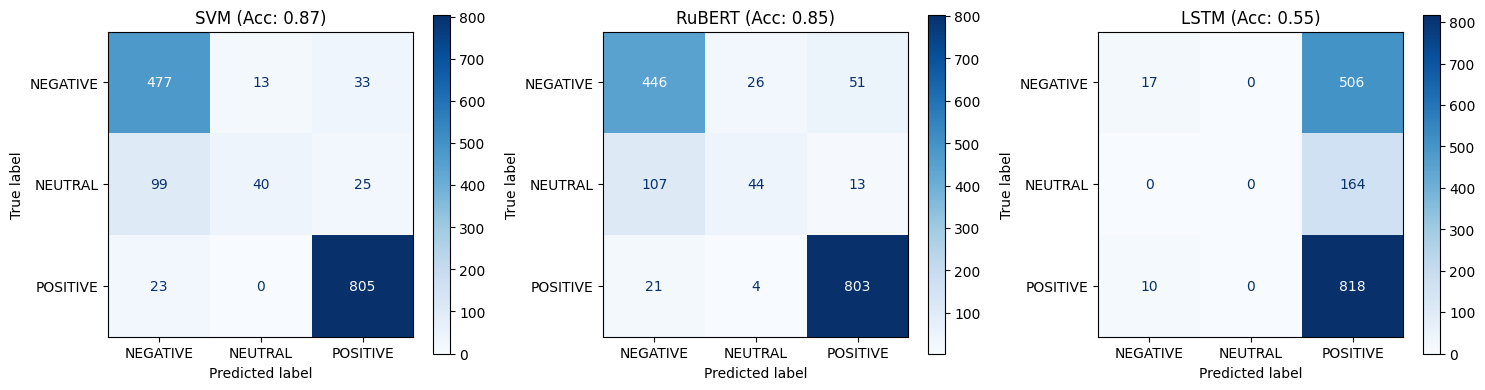


Model: SVM
Accuracy: 0.8726

Classification Report:
              precision    recall  f1-score   support

    NEGATIVE       0.80      0.91      0.85       523
     NEUTRAL       0.75      0.24      0.37       164
    POSITIVE       0.93      0.97      0.95       828

    accuracy                           0.87      1515
   macro avg       0.83      0.71      0.72      1515
weighted avg       0.87      0.87      0.85      1515


Model: RuBERT
Accuracy: 0.8535

Classification Report:
              precision    recall  f1-score   support

    NEGATIVE       0.78      0.85      0.81       523
     NEUTRAL       0.59      0.27      0.37       164
    POSITIVE       0.93      0.97      0.95       828

    accuracy                           0.85      1515
   macro avg       0.77      0.70      0.71      1515
weighted avg       0.84      0.85      0.84      1515


Model: LSTM
Accuracy: 0.5512

Classification Report:
              precision    recall  f1-score   support

    NEGATIVE       0

/Users/a.makienko/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/a.makienko/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/a.makienko/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i

In [8]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

models_results = {
    "SVM": {
        "model": svm_model,
        "y_true": y_test,
        "y_pred": y_pred_svm,
        "classes": ["NEGATIVE", "NEUTRAL", "POSITIVE"]
    },
    "RuBERT": {
        "model": model_rubert,
        "y_true": df_y_test,
        "y_pred": y_pred_rubert,
        "classes": ["NEGATIVE", "NEUTRAL", "POSITIVE"]
    },
    "LSTM": {
        "model": model_lstm,
        "y_true": df_y_test,
        "y_pred": y_pred_lstm,
        "classes": ["NEGATIVE", "NEUTRAL", "POSITIVE"]
    }
}

def plot_confusion_matrices(models_dict):
    n_models = len(models_dict)
    fig, axes = plt.subplots(1, n_models, figsize=(5*n_models, 4))
    
    if n_models == 1:  # Если модель только одна
        axes = [axes]
    
    for ax, (name, data) in zip(axes, models_dict.items()):
        cm = confusion_matrix(data["y_true"], data["y_pred"])
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                     display_labels=data["classes"])
        disp.plot(ax=ax, cmap='Blues')
        ax.set_title(f'{name} (Acc: {accuracy_score(data["y_true"], data["y_pred"]):.2f})')
    
    plt.tight_layout()
    plt.show()

def print_classification_reports(models_dict):
    for name, data in models_dict.items():
        print(f"\n{'='*50}")
        print(f"Model: {name}")
        print(f"Accuracy: {accuracy_score(data['y_true'], data['y_pred']):.4f}")
        print("\nClassification Report:")
        print(classification_report(data['y_true'], data['y_pred'], target_names=data['classes']))

# Визуализация confusion matrix
plot_confusion_matrices(models_results)

# Вывод подробных отчетов
print_classification_reports(models_results)


Сводная таблица метрик

In [9]:
import pandas as pd

def get_metrics_summary(models_dict):
    metrics = []
    for name, data in models_dict.items():
        report = classification_report(data['y_true'], data['y_pred'], 
                                     target_names=data['classes'], 
                                     output_dict=True)
        
        for class_name in data['classes']:
            metrics.append({
                'Model': name,
                'Class': class_name,
                'Precision': report[class_name]['precision'],
                'Recall': report[class_name]['recall'],
                'F1': report[class_name]['f1-score'],
                'Support': report[class_name]['support']
            })
        
        # Добавляем средние значения
        metrics.append({
            'Model': name,
            'Class': 'macro avg',
            'Precision': report['macro avg']['precision'],
            'Recall': report['macro avg']['recall'],
            'F1': report['macro avg']['f1-score'],
            'Support': report['macro avg']['support']
        })
        
        metrics.append({
            'Model': name,
            'Class': 'weighted avg',
            'Precision': report['weighted avg']['precision'],
            'Recall': report['weighted avg']['recall'],
            'F1': report['weighted avg']['f1-score'],
            'Support': report['weighted avg']['support']
        })
    
    return pd.DataFrame(metrics)

# Получаем и выводим сводную таблицу
metrics_df = get_metrics_summary(models_results)
print(metrics_df)

     Model         Class  Precision    Recall        F1  Support
0      SVM      NEGATIVE   0.796327  0.912046  0.850267    523.0
1      SVM       NEUTRAL   0.754717  0.243902  0.368664    164.0
2      SVM      POSITIVE   0.932793  0.972222  0.952099    828.0
3      SVM     macro avg   0.827946  0.709390  0.723677   1515.0
4      SVM  weighted avg   0.866406  0.872607  0.853788   1515.0
5   RuBERT      NEGATIVE   0.777003  0.852772  0.813127    523.0
6   RuBERT       NEUTRAL   0.594595  0.268293  0.369748    164.0
7   RuBERT      POSITIVE   0.926182  0.969807  0.947493    828.0
8   RuBERT     macro avg   0.765927  0.696957  0.710122   1515.0
9   RuBERT  weighted avg   0.838789  0.853465  0.838566   1515.0
10    LSTM      NEGATIVE   0.629630  0.032505  0.061818    523.0
11    LSTM       NEUTRAL   0.000000  0.000000  0.000000    164.0
12    LSTM      POSITIVE   0.549731  0.987923  0.706390    828.0
13    LSTM     macro avg   0.393120  0.340142  0.256070   1515.0
14    LSTM  weighted avg 

/Users/a.makienko/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/a.makienko/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/a.makienko/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i

Определение лучшей модели

In [13]:
from sklearn.metrics import accuracy_score

# Вычисляем точность
acc_svm = accuracy_score(y_test, y_pred_svm)
acc_lstm = accuracy_score(df_y_test, y_pred_lstm)
acc_rubert = accuracy_score(df_y_test, y_pred_rubert)

# Выводим результаты
print(f"Accuracy (SVM): {acc_svm:.4f}")
print(f"Accuracy (LSTM): {acc_lstm:.4f}")
print(f"Accuracy (RuBERT-Tiny2): {acc_rubert:.4f}")

# Определяем лучшую модель
best_model_name = max(
    [("SVM", acc_svm), ("LSTM", acc_lstm), ("RuBERT-Tiny2", acc_rubert)], 
    key=lambda x: x[1]
)[0]

print(f"\nЛучшая модель: {best_model_name}")


Accuracy (SVM): 0.8726
Accuracy (LSTM): 0.5512
Accuracy (RuBERT-Tiny2): 0.8535

Лучшая модель: SVM


Вывод ошибок предсказания

In [14]:
import pandas as pd

# Определяем предсказания лучшей модели
best_predictions = {
    "SVM": y_pred_svm,
    "LSTM": y_pred_lstm,
    "RuBERT-Tiny2": y_pred_rubert
}[best_model_name]

# Создаем DataFrame с ошибками
errors_df = df_X_test.copy()
errors_df["true_label"] = df_y_test.values
errors_df["pred_label"] = best_predictions
errors_df["correct"] = errors_df["true_label"] == errors_df["pred_label"]

# Фильтруем ошибки
errors_only = errors_df[errors_df["correct"] == False].copy()

# Выводим 10 примеров ошибок
print("\nОшибки предсказаний:")
print(errors_only[["review", "true_label", "pred_label"]].head(10))



Ошибки предсказаний:
                                                 review  true_label  \
1150  Очень подробно объяснили мою проблему и предос...           1   
1705  Большое спасибо врачу Кубину Никите Дмитриевич...           2   
7318  При отличных анализах спалили впустую квоту на...           1   
2007  В данной клинике выполнялась компьютерная томо...           2   
7400  Был у многих врачей СМ клиники. В принципе, кл...           1   
6265  Мне вначале тоже показалось, что клиника хорош...           0   
7567  Издеваются над людьми! Держат в заложниках эмб...           1   
1039  Добрый день! Вчера сбежали из этой больницы, 1...           0   
5230  Я даже не был ни минуты с доктором в комнате. ...           0   
4335  В эту клинику попала по рекомендации от знаком...           2   

      pred_label  
1150           0  
1705           0  
7318           0  
2007           0  
7400           2  
6265           2  
7567           0  
1039           2  
5230           2  
4335  

Подбор гиперпараметра для лучшей модели

In [15]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# Определяем параметры для поиска
param_grid = {
    "C": [0.1, 1, 10, 100],  
    "kernel": ["linear", "rbf", "poly", "sigmoid"],  
    "gamma": ["scale", "auto", 0.01, 0.001]  
}

# Запускаем подбор
grid_search = GridSearchCV(SVC(), param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

# Выводим лучшие параметры
best_params = grid_search.best_params_
print("Лучшие параметры SVM:", best_params)

Fitting 5 folds for each of 64 candidates, totalling 320 fits


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=  11.8s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=  11.8s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=  11.9s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=  11.9s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=  11.9s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=  14.3s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=  14.4s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=  14.4s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=  14.6s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=  14.8s
[CV] END ....................C=0.1, gamma=scale, kernel=poly; total time=  16.7s
[CV] END ....................C=0.1, gamma=scale, kernel=poly; total time=  17.2s
[CV] END .................C=

Обучение модели с новым гиперпараметром

In [16]:
# Обучаем SVM с оптимальными параметрами
optimized_svm = SVC(**best_params)
optimized_svm.fit(X_train, y_train)

SVC(C=100, gamma=0.01)

Оценка старой и новой модели

In [17]:
from sklearn.metrics import accuracy_score, classification_report

# Предсказания старой модели
old_svm = SVC()  # Без гиперпараметров
old_svm.fit(X_train, y_train)
old_preds = old_svm.predict(X_test)

# Предсказания новой модели
new_preds = optimized_svm.predict(X_test)

# Оценка старой модели
old_acc = accuracy_score(y_test, old_preds)
print(f"Точность старой модели: {old_acc}")
print("Классификационный отчёт старой модели:\n", classification_report(y_test, old_preds))

# Оценка новой модели
new_acc = accuracy_score(y_test, new_preds)
print(f"Точность новой модели: {new_acc}")
print("Классификационный отчёт новой модели:\n", classification_report(y_test, new_preds))


Точность старой модели: 0.858085808580858
Классификационный отчёт старой модели:
               precision    recall  f1-score   support

           0       0.77      0.93      0.84       523
           1       0.82      0.05      0.10       164
           2       0.93      0.97      0.95       828

    accuracy                           0.86      1515
   macro avg       0.84      0.65      0.63      1515
weighted avg       0.86      0.86      0.82      1515

Точность новой модели: 0.8712871287128713
Классификационный отчёт новой модели:
               precision    recall  f1-score   support

           0       0.81      0.88      0.84       523
           1       0.67      0.36      0.47       164
           2       0.94      0.96      0.95       828

    accuracy                           0.87      1515
   macro avg       0.80      0.74      0.75      1515
weighted avg       0.86      0.87      0.86      1515

